<a href="https://colab.research.google.com/github/Togarucharitha/BEE-102-Spring-2025-Assignment/blob/main/23114100_bee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

**Goal**

The objective is to analyze a dataset containing DNA fragment mappings and compute the distribution of fragment lengths. This involves:

1.Calculating each fragment's length.

2.Counting occurrences of each fragment length.

3.Normalizing these counts to get frequency values.

4.Plotting the normalized frequency distribution with fragment length on the X-axis and normalized frequency on the Y-axis.



**Approach**

1.Reading the File & Extracting Fragment Lengths

*   Open the file line-by-line.
*   Parse the second and third columns to compute the length of each fragment.


*   Handle malformed lines (e.g., missing fields or non-integer values) by skipping them with appropriate warnings.




2.Counting Fragment Lengths


*   Use Python's Counter from the collections module to tally how many times each fragment length appears.

3.Normalizing Frequencies

Convert raw counts to normalized

*   Convert raw counts to normalized frequencies by dividing each count by the total number of fragments.
*   This ensures the Y-axis values range from 0 to 1 and reflect relative frequencies.

4.Sorting and Plotting

*  Sort the fragment lengths for better visual interpretation.
*   Use matplotlib.pyplot to create a bar chart:
    
    X-axis: Fragment lengths (in base pairs).

    Y-axis: Normalized frequency, labeled as "Normalized Frequency [A.U.]" (Arbitrary Units).




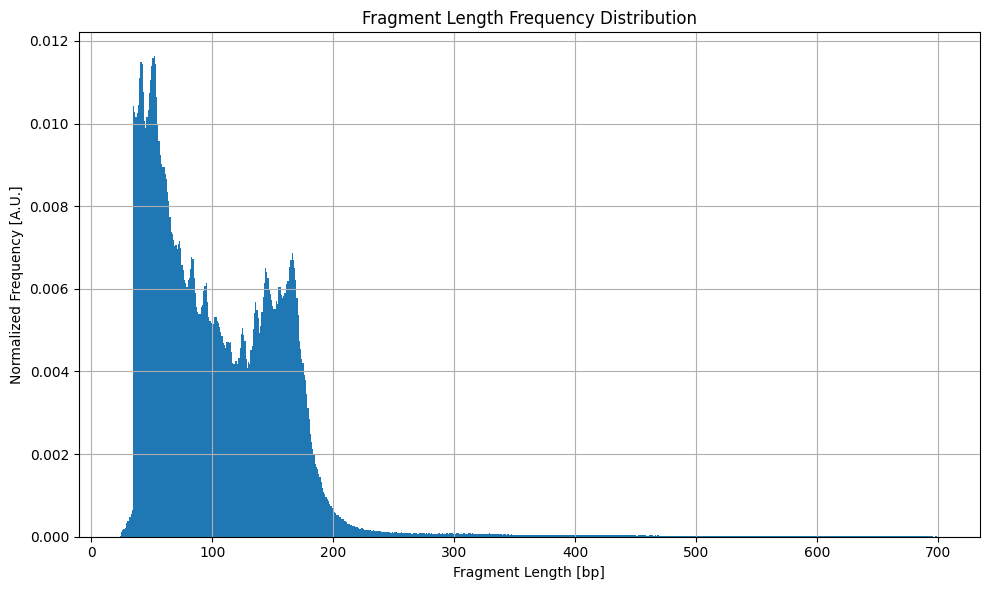

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import gzip

file_path = '/content/query.bed'
# Step 1: Read data
fragment_lengths = []
with open(file_path, "r") as file:
    for line in file:
        parts = line.strip().split('\t')
         # Check if the line has enough fields
        if len(parts) >= 3:
            try:
                start = int(parts[1])
                end = int(parts[2])
                length = end - start
                fragment_lengths.append(length)
            except ValueError:
                print(f"Skipping line due to ValueError: {line.strip()}") # Print problematic line
                continue
        else:
            print(f"Skipping line due to insufficient fields: {line.strip()}") # Print problematic line
            continue

# Step 2: Count frequency of each length
length_counts = Counter(fragment_lengths)

# Step 3: Normalize frequencies
total_fragments = sum(length_counts.values())
normalized_freq = {length: count / total_fragments for length, count in length_counts.items()}

# Step 4: Sort by fragment length for plotting
sorted_lengths = sorted(normalized_freq.keys())
normalized_values = [normalized_freq[length] for length in sorted_lengths]

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.bar(sorted_lengths, normalized_values, width=1.0)
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Frequency Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()



**Goal**

The objective is to rescale a set of query DNA fragments such that their length distribution closely matches a given reference distribution. This is achieved by subsampling the query fragments to conform to the reference histogram and then plotting the distributions for comparison.


**Approach**

1.Load the Reference Histogram



*  Read reference.hist into a dictionary mapping each fragment length to its normalized frequency.




2.Parse the Query BED File and Group by Length


*   Read each line from the query.bed file.
*   Compute the fragment length (end - start) and group the full lines by length using a defaultdict(list).





3.Compute the Query Distribution


*   Count how many fragments belong to each length.
*   Normalize these counts by the total number of fragments to compute the query’s empirical frequency distribution.






4.Determine a Global Scaling Factor



*   For each length present in both reference and query, compute the ratio of reference frequency to query frequency.
*   The smallest such ratio is used as a global scale factor to ensure we do not oversample any length class during subsampling.



5.Subsample Query Fragments to Match Reference

For each fragment length in the reference:

Calculate the number of fragments needed from the query using the scale factor.

Randomly sample from the available query fragments of that length, if enough exist.

6.Collect all sampled fragments into a new list.

Compute and Normalize the Rescaled Distribution

Extract fragment lengths from the resampled data.

Count and normalize the distribution just like before.

7.Plot the Distributions

Plot three lines:

Reference: Dashed black line.

Original query: Dotted red line.

Rescaled query: Solid blue line.

X-axis: Fragment length [bp]

Y-axis: Normalized frequency [A.U.]



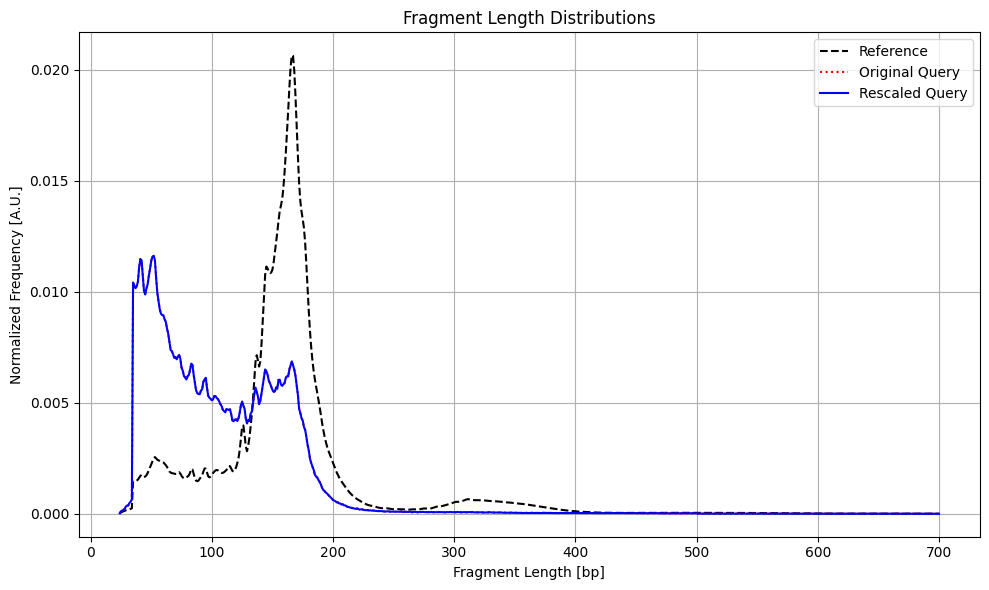

In [4]:
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import random

# Step 1: Load reference histogram
reference_hist = {}
with open("reference.hist", "r") as ref_file:
    for line in ref_file:
        if line.strip():
            length, freq = line.strip().split()
            reference_hist[int(length)] = float(freq)

# Step 2: Load query BED and compute fragment lengths
query_fragments = defaultdict(list)  # maps length to list of lines
with open("query.bed", "r") as query_file:
    for line in query_file:
        parts = line.strip().split()
        if len(parts) >= 3:
            try:
                start = int(parts[1])
                end = int(parts[2])
                length = end - start
                if length > 0:
                    query_fragments[length].append(line.strip())
            except ValueError:
                continue

# Step 3: Normalize query distribution
query_counts = {length: len(lines) for length, lines in query_fragments.items()}
total_query = sum(query_counts.values())
query_freqs = {length: count / total_query for length, count in query_counts.items()}

# Step 4: Rescale (subsample) query to match reference
# Determine the smallest scale factor to avoid oversampling
scale_factors = []
for length in reference_hist:
    if length in query_freqs and query_freqs[length] > 0:
        scale_factors.append(reference_hist[length] / query_freqs[length])
scale_factor = min(scale_factors) if scale_factors else 0

# Resample accordingly
rescaled_fragments = []
for length in reference_hist:
    if length in query_fragments:
        target_fraction = reference_hist[length]
        num_to_sample = int(target_fraction / scale_factor * total_query)
        available_fragments = query_fragments[length]
        if num_to_sample > len(available_fragments):
            sampled = available_fragments  # Use all available
        else:
            sampled = random.sample(available_fragments, num_to_sample)
        rescaled_fragments.extend(sampled)

# Step 5: Compute fragment length distribution of rescaled data
rescaled_lengths = [int(line.split()[2]) - int(line.split()[1]) for line in rescaled_fragments]
rescaled_counts = Counter(rescaled_lengths)
total_rescaled = sum(rescaled_counts.values())
normalized_rescaled = {length: count / total_rescaled for length, count in rescaled_counts.items()}

# Step 6: Plot all three distributions
plt.figure(figsize=(10, 6))

# Reference distribution
ref_lengths = sorted(reference_hist.keys())
ref_values = [reference_hist[length] for length in ref_lengths]
plt.plot(ref_lengths, ref_values, label="Reference", color='black', linestyle='--')

# Original query distribution
orig_lengths = sorted(query_freqs.keys())
orig_values = [query_freqs[length] for length in orig_lengths]
plt.plot(orig_lengths, orig_values, label="Original Query", color='red', linestyle=':')

# Rescaled query distribution
res_lengths = sorted(normalized_rescaled.keys())
res_values = [normalized_rescaled.get(length, 0) for length in res_lengths]
plt.plot(res_lengths, res_values, label="Rescaled Query", color='blue')

# Plot decorations
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Question 2


This solution resamples a query DNA fragment dataset to match a reference length distribution. It starts by reading normalized frequencies from reference.hist and fragment data from query.bed, calculating fragment lengths as the difference between end and start positions. The query fragments are grouped by length and their frequencies normalized.

A global scale factor is computed to avoid oversampling, based on the ratio of reference to query frequencies. Using this factor, the script subsamples the query fragments for each length to approximate the reference distribution. It then recalculates the normalized frequencies of the rescaled dataset and plots three distributions—reference, original query, and rescaled query—allowing visual comparison of how closely the rescaled data matches the reference.

In [2]:
from collections import defaultdict

# File path
file_path = "/content/multiline_input.fasta"

# Initialize transition count dictionary
transition_counts = defaultdict(lambda: defaultdict(int))

# Define valid nucleotides
valid_nucleotides = {'A', 'C', 'G', 'T'}

# Initialize previous character (for building dinucleotides)
prev_char = None

with open(file_path, "r") as file:
    for line in file:
        if line.startswith(">"):
            continue  # skip FASTA header
        line = line.strip().upper()
        for char in line:
            if char not in valid_nucleotides:
                prev_char = None
                continue
            if prev_char:
                transition_counts[prev_char][char] += 1
            prev_char = char

# Build and print normalized transition matrix
print("Markov Transition Matrix (1st order):")
nucleotides = ['A', 'C', 'G', 'T']
print("  From\\To  " + "  ".join(nucleotides))

for from_nuc in nucleotides:
    total = sum(transition_counts[from_nuc].values())
    row = [from_nuc]
    for to_nuc in nucleotides:
        prob = (transition_counts[from_nuc][to_nuc] / total) if total > 0 else 0
        row.append(f"{prob:.4f}")
    print(f"{row[0]:>8} {'  '.join(row[1:])}")


Markov Transition Matrix (1st order):
  From\To  A  C  G  T
       A 0.2509  0.2426  0.2648  0.2417
       C 0.2465  0.2544  0.2449  0.2541
       G 0.2518  0.2474  0.2556  0.2452
       T 0.2709  0.2374  0.2502  0.2414


# Question 3


This task aims to convert multi-line FASTA files into a simpler format where each sequence is written in a single line following its header. This helps avoid issues with sequence searches that span line breaks, such as failing to find patterns split across lines.

The provided solution reads through the file line by line without storing large sequences in memory using lists, making it efficient for large files like whole chromosomes. It tracks whether the current line is a header (starting with >), in which case it prints it directly. For sequence lines, it strips newline characters and prints them continuously on the same line until the next header is encountered. This keeps memory usage minimal while producing correctly formatted single-line FASTA output.

In [5]:
# Convert multiline FASTA to single-line FASTA
def convert_multiline_to_singleline_fasta(input_path, output_path):
    with open(input_path, 'r') as infile, open(output_path, 'w') as outfile:
        current_header = None
        current_sequence = ""

        for line in infile:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_header is not None:
                    outfile.write(current_header + "\n")
                    outfile.write(current_sequence + "\n")
                current_header = line
                current_sequence = ""
            else:
                current_sequence += line

        # Write the last entry
        if current_header is not None:
            outfile.write(current_header + "\n")
            outfile.write(current_sequence + "\n")

# Usage
convert_multiline_to_singleline_fasta("multiline_input.fasta", "singleline_output.fasta")


# Question 4


This solution implements the Viterbi algorithm to infer the most likely sequence of hidden states (exon, 5′ splice site, intron) that would emit a given DNA sequence, based on a probabilistic model described in the Nature Primer.

The algorithm starts by defining the model parameters: the states (E, 5, and I), transition probabilities (including special Start and End states), and emission probabilities for each nucleotide from each state. All probabilities are converted to log-space to prevent numerical underflow and allow for summation instead of multiplication.

A helper function get_log_prob_of_a_given_path is defined to compute the total log probability of a specific path through the model given a DNA sequence. This allows validation against known paths, such as "EEEEEEEEEEEEEEEEEE5IIIIIII" for the sequence "CTTCATGTGAAAGCAGACGTAAGTCA", which yields a reference value of -41.22.

The Viterbi function itself initializes the log-probability matrix for the first base, then recursively fills in probabilities for subsequent positions by considering the best transition from each previous state. For each step, it records the most probable path to each state. After processing the full sequence, it chooses the final state with the highest probability and traces back the most likely path.

Finally, it prints the log probability of the known path, the inferred most likely path, its log probability, and optionally detects the location of a 5′ splice site (5 state) if present.

This approach effectively combines hidden Markov models and dynamic programming to perform biologically meaningful sequence annotation.

In [6]:
import math

# Log helper to handle zero probabilities
def safe_log(p):
    return math.log(p) if p > 0 else float('-inf')

# Define states
states = ['E', '5', 'I']

# Transition probabilities (log)
transition = {
    'Start': {'E': safe_log(1.0)},
    'E': {'E': safe_log(0.9), '5': safe_log(0.1)},
    '5': {'I': safe_log(1.0)},
    'I': {'I': safe_log(0.9), 'End': safe_log(0.1)}  # No I → E transition
}

# Emission probabilities (log)
emission = {
    'E': {'A': safe_log(0.25), 'C': safe_log(0.25), 'G': safe_log(0.25), 'T': safe_log(0.25)},
    '5': {'A': safe_log(0.05), 'C': float('-inf'), 'G': safe_log(0.95), 'T': float('-inf')},
    'I': {'A': safe_log(0.4), 'C': safe_log(0.1), 'G': safe_log(0.1), 'T': safe_log(0.4)},
}

# Compute log probability of a given path and sequence
def get_log_prob_of_a_given_path(path, sequence):
    total_log_prob = 0.0
    # Initial transition from Start
    total_log_prob += transition['Start'][path[0]]
    for i in range(len(sequence)):
        s = path[i]
        o = sequence[i]
        total_log_prob += emission[s].get(o, float('-inf'))
        if i < len(sequence) - 1:
            total_log_prob += transition[s].get(path[i + 1], float('-inf'))
        else:
            # Final transition to End if applicable
            if 'End' in transition.get(s, {}):
                total_log_prob += transition[s]['End']
    return total_log_prob

# Viterbi algorithm
def viterbi(sequence):
    V = [{}]
    path = {}

    # Initialization
    for state in states:
        V[0][state] = transition['Start'].get(state, float('-inf')) + emission[state].get(sequence[0], float('-inf'))
        path[state] = [state]

    # Recursion
    for t in range(1, len(sequence)):
        V.append({})
        new_path = {}
        for curr_state in states:
            max_prob, prev_st = max(
                ((V[t-1][prev_state] + transition[prev_state].get(curr_state, float('-inf')) +
                  emission[curr_state].get(sequence[t], float('-inf')), prev_state)
                 for prev_state in states if prev_state in transition and curr_state in transition[prev_state]),
                default=(float('-inf'), None)
            )
            V[t][curr_state] = max_prob
            if prev_st:
                new_path[curr_state] = path[prev_st] + [curr_state]
        path = new_path

    # Termination
    n = len(sequence) - 1
    final_probs = {}
    for state in states:
        final_probs[state] = V[n][state] + transition.get(state, {}).get('End', 0)

    best_final_state = max(final_probs, key=final_probs.get)
    return path[best_final_state], final_probs[best_final_state]

# Input
sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"
known_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"

# Run
log_prob_known = get_log_prob_of_a_given_path(known_path, sequence)
viterbi_path, viterbi_log_prob = viterbi(sequence)

# Output
print(f"Log probability of known path: {log_prob_known:.2f}")
print(f"Most likely path: {''.join(viterbi_path)}")
print(f"Log probability of Viterbi path: {viterbi_log_prob:.2f}")

# Optional: detect 5' splice site
if '5' in viterbi_path:
    splice_index = viterbi_path.index('5')
    print(f"Detected 5′ splice site at position: {splice_index} (base = {sequence[splice_index]})")
else:
    print("No 5′ splice site detected in the Viterbi path.")

Log probability of known path: -41.22
Most likely path: EEEEEEEEEEEEEEEEEEEEEEEEEE
Log probability of Viterbi path: -38.68
No 5′ splice site detected in the Viterbi path.


# Question 5


This solution generates a V-plot, a heatmap that visualizes DNA fragment sizes relative to protein binding sites. The goal is to reveal protected regions where proteins bind—typically forming a "V" shape due to fragment distributions flanking the center.

The process begins by parsing a tab-delimited file where each line represents a fragment and its associated binding site. From each line, the script calculates:

X: the distance from the fragment center to the protein binding center,

Y: the fragment length,

Z: the count of how often a particular (X, Y) pair occurs.

All (X, Y) occurrences are aggregated into a count_map. These are used to build a 2D matrix (heatmap) with fragment length (Y) on the vertical axis and position relative to the protein binding center (X) on the horizontal axis. The values in the matrix represent how many times a fragment of length Y occurred at position X.

Finally, the heatmap is rendered using Seaborn with an inverted Y-axis to match biological conventions, revealing the characteristic V-pattern of protected fragments near binding sites.

In [24]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Compressed input file
file_path = "/content/data.bed"

# Count occurrences of (X, Y)
count_map = defaultdict(int)

# Open and read compressed file
with open(file_path, 'r') as file:
    for line in file:
        fields = line.strip().split('\t')

        # Check if the line has enough fields before accessing them
        if len(fields) >= 10:
            # Center of protein-bound region (col 3 & 4)
            center_protein = (int(fields[2]) + int(fields[3])) // 2

            # Center of fragment (col 9 & 10)
            center_fragment = (int(fields[8]) + int(fields[9])) // 2

            # X = offset from protein binding center
            x = center_fragment - center_protein

            # Y = fragment length
            y = int(fields[9]) - int(fields[8])

            # Count the (X, Y) occurrence
            count_map[(x, y)] += 1
        #else:
        #    print(f"Skipping line due to insufficient fields: {line.strip()}")  # Optional: Print skipped lines

print("Total unique (X, Y) pairs:", len(count_map))

Total unique (X, Y) pairs: 122906


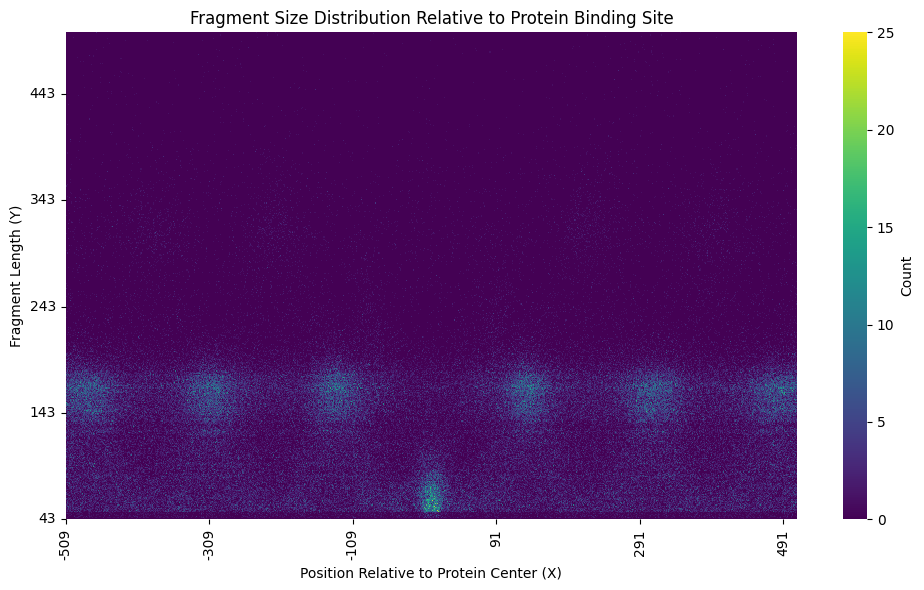

In [23]:
# Create sorted unique lists of X and Y
x_vals = sorted({x for x, _ in count_map})
y_vals = sorted({y for _, y in count_map})

# Index maps for matrix placement
x_index = {x: i for i, x in enumerate(x_vals)}
y_index = {y: i for i, y in enumerate(y_vals)}

# Create heatmap matrix
heatmap = np.zeros((len(y_vals), len(x_vals)))
for (x, y), count in count_map.items():
    heatmap[y_index[y], x_index[x]] = count

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, cmap="viridis", cbar_kws={'label': 'Count'})
plt.gca().invert_yaxis()
plt.xticks(np.arange(len(x_vals))[::200], x_vals[::200])
plt.yticks(np.arange(len(y_vals))[::100], y_vals[::100])
plt.title("Fragment Size Distribution Relative to Protein Binding Site")
plt.xlabel("Position Relative to Protein Center (X)")
plt.ylabel("Fragment Length (Y)")
plt.tight_layout()
plt.show()

# Question 6


The code performs PCA on gene expression data from 105 breast cancer patients to uncover patterns of variance. It visualizes the expression of key genes (GATA3 and XBP1), projects samples onto principal components, and highlights how PC1 separates ER+ and ER− classes, effectively reproducing Figure 1 of the Nature primer.

Class data shape: (105, 1)
Expression data shape: (105, 16173)


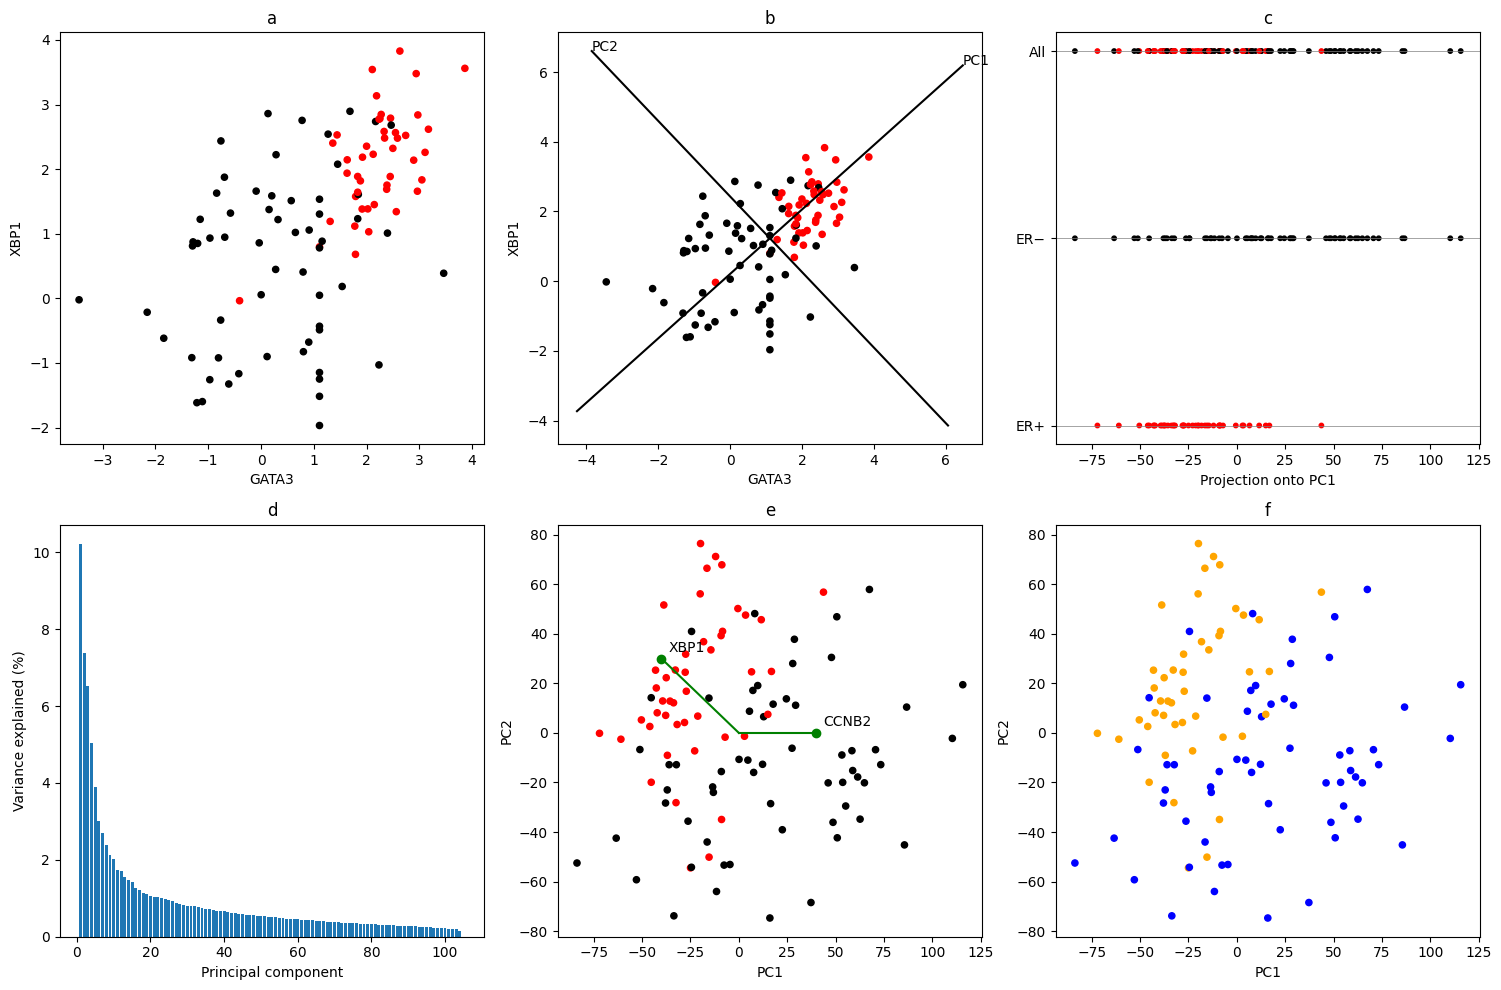

Explained variance ratio for PC1: 0.102
Explained variance ratio for PC2: 0.074


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import gzip
from io import StringIO

# --------------------------
# Load class data
# --------------------------
class_data = pd.read_csv('class.tsv', sep='\t', header=None)
print("Class data shape:", class_data.shape)

# --------------------------
# Load expression data
# --------------------------
with gzip.open('filtered.tsv.gz', 'rt') as f:
    expression_data = pd.read_csv(f, sep='\t', index_col=0)
expression_data.columns = expression_data.columns.astype(str).str.strip()
print("Expression data shape:", expression_data.shape)

# --------------------------
# Load gene mapping
# --------------------------
with gzip.open('columns.tsv.gz', 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]
gene_mapping = pd.read_csv(StringIO(''.join(lines)), sep='\t')

def find_gene_id(gene_name):
    matches = gene_mapping[gene_mapping['GeneSymbol'] == gene_name]
    if len(matches) > 0:
        return str(matches['ID'].iloc[0])
    return None

xbp1_id = '4404'  # Known from paper
gata3_id = find_gene_id('GATA3')

if xbp1_id is not None and gata3_id is not None:
    xbp1_expression = expression_data[xbp1_id].values
    gata3_expression = expression_data[gata3_id].values

    colors = ['red' if c == 1 else 'black' for c in class_data[0]]

    # PCA for full expression matrix
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(expression_data.values)
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(15, 10))

    # a. Scatter: GATA3 vs XBP1
    plt.subplot(2, 3, 1)
    plt.scatter(gata3_expression, xbp1_expression, c=colors, s=20)
    plt.xlabel('GATA3')
    plt.ylabel('XBP1')
    plt.title('a')

    # b. PCA Vectors on 2D plot
    plt.subplot(2, 3, 2)
    plt.scatter(gata3_expression, xbp1_expression, c=colors, s=20)
    center = np.mean(np.vstack([gata3_expression, xbp1_expression]), axis=1)
    pca_2d = PCA()
    pca_2d.fit(np.column_stack((gata3_expression, xbp1_expression)))
    pc1, pc2 = pca_2d.components_

    scale = max(np.ptp(gata3_expression), np.ptp(xbp1_expression))
    plt.plot([center[0] - pc1[0]*scale, center[0] + pc1[0]*scale],
             [center[1] - pc1[1]*scale, center[1] + pc1[1]*scale], 'k-', label='PC1')
    plt.plot([center[0] - pc2[0]*scale, center[0] + pc2[0]*scale],
             [center[1] - pc2[1]*scale, center[1] + pc2[1]*scale], 'k-', label='PC2')
    plt.annotate('PC1', (center[0] + pc1[0]*scale, center[1] + pc1[1]*scale))
    plt.annotate('PC2', (center[0] + pc2[0]*scale, center[1] + pc2[1]*scale))
    plt.xlabel('GATA3')
    plt.ylabel('XBP1')
    plt.title('b')

    # c. Projected onto PC1
    # c. Projected samples on PC1
    plt.subplot(2, 3, 3)

    proj_pc1 = X_pca[:, 0]
    labels = class_data[0].values

    proj_all = proj_pc1
    proj_er_neg = proj_pc1[labels == 0]
    proj_er_pos = proj_pc1[labels == 1]

    colors_all = ['red' if l == 1 else 'black' for l in labels]
    colors_er_neg = ['black'] * sum(labels == 0)
    colors_er_pos = ['red'] * sum(labels == 1)

    y_offsets = [2, 1, 0]  # All, ER−, ER+

    plt.scatter(proj_all, [y_offsets[0]] * len(proj_all), c=colors_all, s=10, label='All')
    plt.scatter(proj_er_neg, [y_offsets[1]] * len(proj_er_neg), c=colors_er_neg, s=10, label='ER−')
    plt.scatter(proj_er_pos, [y_offsets[2]] * len(proj_er_pos), c=colors_er_pos, s=10, label='ER+')

    plt.yticks(y_offsets, ['All', 'ER−', 'ER+'])
    plt.xlabel('Projection onto PC1')
    plt.title('c')
    plt.axhline(y=y_offsets[0], color='gray', linewidth=0.5)
    plt.axhline(y=y_offsets[1], color='gray', linewidth=0.5)
    plt.axhline(y=y_offsets[2], color='gray', linewidth=0.5)


    # d. Scree plot
    plt.subplot(2, 3, 4)
    plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_ * 100)
    plt.xlabel('Principal component')
    plt.ylabel('Variance explained (%)')
    plt.title('d')

    # e. PC2 vs PC1 with gene vectors
    plt.subplot(2, 3, 5)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=20)
    plt.plot([0, -40], [0, 30], 'g-')
    plt.plot([0, 40], [0, 0], 'g-')
    plt.scatter([-40, 40], [30, 0], c='green')
    plt.annotate('XBP1', (-40, 30), textcoords='offset points', xytext=(5, 5))
    plt.annotate('CCNB2', (40, 0), textcoords='offset points', xytext=(5, 5))
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('e')

    # f. PC2 vs PC1 (colored)
    plt.subplot(2, 3, 6)
    colors_f = ['orange' if c == 1 else 'blue' for c in class_data[0]]
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_f, s=20)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('f')

    plt.tight_layout()
    plt.show()

    print(f"Explained variance ratio for PC1: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"Explained variance ratio for PC2: {pca.explained_variance_ratio_[1]:.3f}")

else:
    print("XBP1 or GATA3 not found in gene mapping")
